In [ ]:
#Phùng Trí Quân

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import os

#  Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

#  ĐƯỜNG DẪN THƯ MỤC datadoan
data_dir = "/content/drive/MyDrive/datadoan"

#  Mở / kiểm tra thư mục datadoan
print(" Nội dung thư mục datadoan:")
print(os.listdir(data_dir))


Mounted at /content/drive
 Nội dung thư mục datadoan:
['plant-health']


In [2]:
DATA_DIR = "/content/drive/MyDrive/datadoan/plant-health"
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
EPOCHS = 5


Found 566 images belonging to 2 classes.
Found 141 images belonging to 2 classes.
Số lớp: 2
Các lớp: ['healthy', 'unhealthy']


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,402,050 (20.61 MB)

 Trainable params: 5,402,050 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 113s 6s/step - accuracy: 0.5411 - loss: 1.0468 - val_accuracy: 0.5390 - val_loss: 0.7502
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.6168 - loss: 0.6422 - val_accuracy: 0.5035 - val_loss: 0.6972
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.6439 - loss: 0.6220 - val_accuracy: 0.5461 - val_loss: 0.6874
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.7516 - loss: 0.5100 - val_accuracy: 0.6028 - val_loss: 0.6521
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.8387 - loss: 0.3640 - val_accuracy: 0.5745 - val_loss: 0.9824

Độ chính xác trên tập validation: 0.5745
Giá trị loss trên tập validation: 1.0056


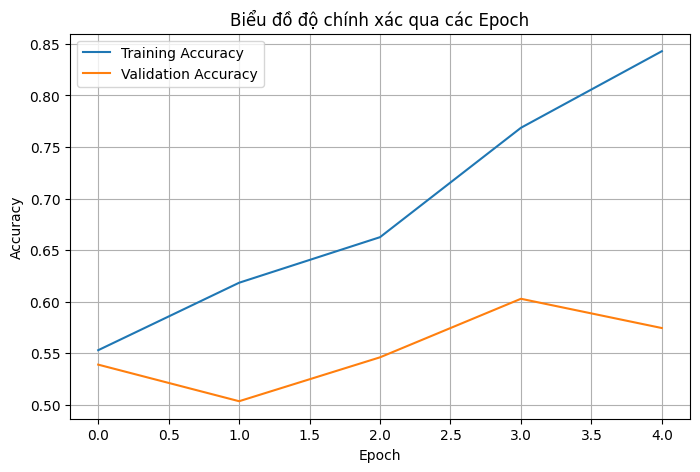

Naive Bayes - Shape X: (707, 67500)
Naive Bayes - Shape y: (707,)

Độ chính xác Naive Bayes: 0.6619718309859155

Báo cáo phân loại Naive Bayes:
              precision    recall  f1-score   support

     healthy       0.60      0.80      0.68        65
   unhealthy       0.76      0.55      0.64        77

    accuracy                           0.66       142
   macro avg       0.68      0.67      0.66       142
weighted avg       0.69      0.66      0.66       142


SO SÁNH MÔ HÌNH
CNN Accuracy       : 0.5745
Naive Bayes Accuracy: 0.6620


In [3]:
# 3. Tiền xử lý & Tăng cường dữ liệu (Augmentation)
# Sử dụng ImageDataGenerator để rescale ảnh, xoay, dịch chuyển, phóng to/thu nhỏ và lật ngang
# Chia tập train/validation dựa trên VAL_SPLIT
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=VAL_SPLIT
)

# Generator cho tập train
train_gen = train_datagen.flow_from_directory(
    directory=DATA_DIR,          # thư mục chứa các folder class
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Generator cho tập validation
val_gen = train_datagen.flow_from_directory(
    directory=DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Lấy tên các lớp
class_names = list(train_gen.class_indices.keys())
num_classes = len(class_names)

print("Số lớp:", num_classes)
print("Các lớp:", class_names)


# 4. Xây dựng mô hình CNN (phù hợp dataset Lettuce Health)
# Sử dụng 3 tầng Conv2D + MaxPooling, Flatten, Dense + Dropout, output softmax
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),   # (150,150,3)
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),   # tăng nhẹ để chống overfitting
    layers.Dense(len(class_names), activation='softmax')
])
model.summary()

# 5. Compile mô hình
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Huấn luyện mô hình
# epochs: số lần mô hình học qua toàn bộ tập huấn luyện

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    verbose=1
)

# 7. Đánh giá mô hình trên tập validation
val_loss, val_acc = model.evaluate(val_gen, verbose=0)

print(f"\nĐộ chính xác trên tập validation: {val_acc:.4f}")
print(f"Giá trị loss trên tập validation: {val_loss:.4f}")

# 8. Biểu đồ Accuracy theo epoch
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Biểu đồ độ chính xác qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


#MÔ HÌNH NAIVE BAYES
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
#Load & chuẩn hoá dữ liệu ảnh cho Naive Bayes
X = []
y = []
class_names = sorted(os.listdir(DATA_DIR))
for label, class_name in enumerate(class_names):
    class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img, IMG_SIZE)
        img = img / 255.0          # chuẩn hoá giống CNN
        img = img.flatten()        # chuyển ảnh thành vector 1D
        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)
print("Naive Bayes - Shape X:", X.shape)
print("Naive Bayes - Shape y:", y.shape)

#Chia tập train
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=VAL_SPLIT,
    random_state=42,
    stratify=y
)
#Huấn luyện mô hình Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

#Đánh giá mô hình Naive Bayes
y_pred = nb_model.predict(X_val)
nb_acc = accuracy_score(y_val, y_pred)
print("\nĐộ chính xác Naive Bayes:", nb_acc)
print("\nBáo cáo phân loại Naive Bayes:")
print(classification_report(y_val, y_pred, target_names=class_names))

#SO SÁNH CNN & NAIVE BAYES
print("\nSO SÁNH MÔ HÌNH")
print(f"CNN Accuracy       : {val_acc:.4f}")
print(f"Naive Bayes Accuracy: {nb_acc:.4f}")



In [4]:
from google.colab import files
from tensorflow.keras.preprocessing import image
# Upload ảnh
uploaded = files.upload()
for fname in uploaded.keys():
    # Đọc và chuẩn hóa ảnh
    img_path = fname
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array_exp = np.expand_dims(img_array, axis=0)

    # Dự đoán với CNN
    cnn_pred_prob = model.predict(img_array_exp)
    cnn_pred_label = class_names[np.argmax(cnn_pred_prob)]
    print(f"CNN dự đoán: {cnn_pred_label}")

    # Dự đoán với Naive Bayes
    nb_input = img_array.flatten().reshape(1, -1)
    nb_pred_label = class_names[nb_model.predict(nb_input)[0]]
    print(f"Naive Bayes dự đoán: {nb_pred_label}")


Saving 20230623161250.jpg to 20230623161250.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
CNN dự đoán: unhealthy
Naive Bayes dự đoán: unhealthy


In [ ]:
#Nguyễn Anh Vũ

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import time

#  Khai báo các tham số
DATASET_PATH = "/content/drive/MyDrive/datadoan"
IMG_SIZE = (224, 224)  # thống nhất với generator
BATCH_SIZE = 32
EPOCHS = 5

#  ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

#  Train generator
train_generator = datagen.flow_from_directory(
    directory=DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

#  Validation generator
val_generator = datagen.flow_from_directory(
    directory=DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)



Found 566 images belonging to 1 classes.
Found 141 images belonging to 1 classes.


In [17]:
#  MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)  # (224,224,3)
)

base_model.trainable = False  # đóng băng backbone

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)



In [18]:
# Train model
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

train_time = time.time() - start_time
print(f" Thời gian huấn luyện: {train_time:.2f} giây")


Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 124s 6s/step - accuracy: 0.5907 - loss: 0.8053 - val_accuracy: 1.0000 - val_loss: 0.0113
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.9984 - loss: 0.0375 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 1.0000 - loss: 0.0146 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 1.0000 - loss: 0.0097 - val_accuracy: 1.0000 - val_loss: 8.9284e-04
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 5.2955e-04
 Thời gian huấn luyện: 320.49 giây


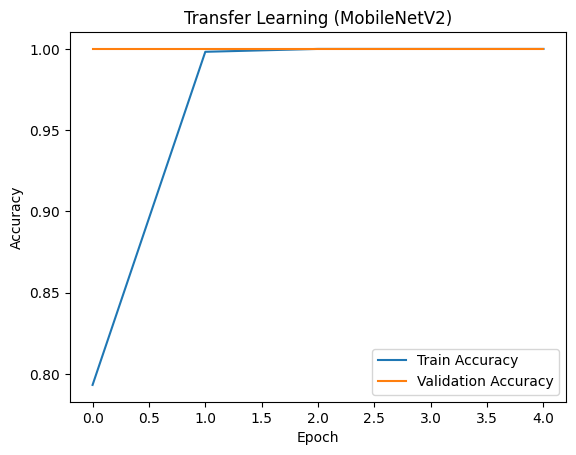

In [19]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning (MobileNetV2)")
plt.legend()
plt.show()


5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
Accuracy trên tập validation: 1.0000

Classification Report:
              precision    recall  f1-score   support

plant-health       1.00      1.00      1.00       141

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



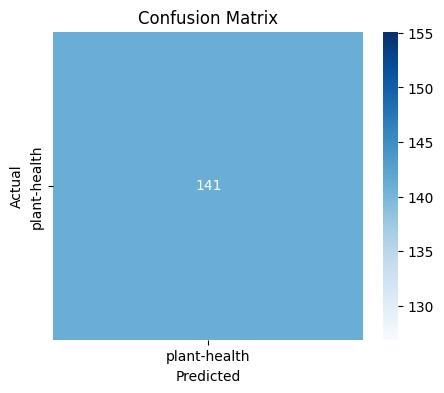

In [21]:
# Import các hàm cần thiết
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy nhãn thật
y_true = val_generator.classes

# Dự đoán
y_pred_prob = model.predict(val_generator)           # ra xác suất
y_pred = (y_pred_prob > 0.5).astype(int).ravel()    # chuyển sang nhãn 0 hoặc 1

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy trên tập validation: {acc:.4f}\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

# Confusion Matrix trực quan
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


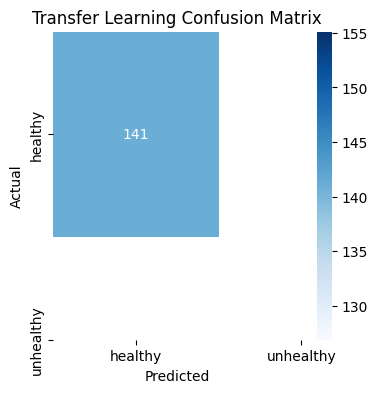

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["healthy", "unhealthy"],
    yticklabels=["healthy", "unhealthy"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Transfer Learning Confusion Matrix")
plt.show()


In [23]:
print(f"Thời gian huấn luyện: {train_time:.2f} giây")


Thời gian huấn luyện: 320.49 giây


In [ ]:
#Võ Hoàn Lạc

In [27]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "/content/drive/MyDrive/datadoan"



In [29]:
from torchvision import transforms
# Tiền xử lý & Augmentation
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


In [31]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
# Chia Train / Val / Test
dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
class_names = dataset.classes
print("Classes:", class_names)

train_size = int(0.7 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

val_ds.dataset.transform = test_transform
test_ds.dataset.transform = test_transform

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)


Classes: ['plant-health']


In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
# Xây dựng CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [34]:
model = SimpleCNN().to(device)


In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [36]:
# Compile & Train CNN
def train_cnn(model, train_loader, val_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss:.4f}")


In [37]:
train_cnn(model, train_loader, val_loader, epochs=10)


Epoch 1/10 - Loss: 0.7254
Epoch 2/10 - Loss: 0.0000
Epoch 3/10 - Loss: 0.0000
Epoch 4/10 - Loss: 0.0000
Epoch 5/10 - Loss: 0.0000
Epoch 6/10 - Loss: 0.0000
Epoch 7/10 - Loss: 0.0000
Epoch 8/10 - Loss: 0.0000
Epoch 9/10 - Loss: 0.0000
Epoch 10/10 - Loss: 0.0000


In [38]:
#Đánh giá CNN (Accuracy – CM – F1)
def evaluate_cnn(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=class_names))

    return y_true, y_pred


In [39]:
# Dự đoán ảnh mới
def predict_image(img_path, model):
    img = Image.open(img_path).convert("RGB")
    img = test_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img)
        pred = torch.argmax(output, 1).item()

    print("Prediction:", class_names[pred])


In [41]:
from PIL import Image
predict_image("/content/drive/MyDrive/datadoan/plant-health/healthy/20230619-9.jpg", model)


Prediction: plant-health


In [42]:
#Trích ảnh từ CNN
def extract_features(model, loader):
    model.eval()
    features, labels = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            x = model.features(imgs)
            x = x.view(x.size(0), -1)

            features.append(x.cpu().numpy())
            labels.append(lbls.numpy())

    return np.vstack(features), np.hstack(labels)


In [43]:
X_train, y_train = extract_features(model, train_loader)
X_test,  y_test  = extract_features(model, test_loader)
